# Notebook 06 — Batch Calibration and Hurst Exponent Dynamics

Loads real saved calibration results from `results/hurst_dynamics/SPX_hurst_study.json`,
plots the evolution of all Rough Heston parameters, and analyses the Hurst exponent H.
If no saved results exist, runs a short demo calibration over 5 dates.

**Runtime estimate:** 30 sec (from saved JSON) or 10–20 min (live calibration)

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

import json
from pathlib import Path
from calibration.batch_calibration import (
    calibrate_batch, results_to_dataframe, load_results, save_results
)
RESULTS_PATH = "../results/hurst_dynamics/SPX_hurst_study.json"


Device: cuda


## 1. Load or Generate Calibration Results

In [2]:
p = Path(RESULTS_PATH)
if p.exists():
    results = load_results(RESULTS_PATH)
    df = results_to_dataframe(results)
    print(f"Loaded {len(df)} calibration results from saved file.")
else:
    print("No saved results found. Running short demo (5 dates) ...")
    # Run batch calibration over 5 recent dates
    demo_dates = ["2024-01-02", "2024-01-03", "2024-01-04",
                  "2024-01-05", "2024-01-08"]
    results = calibrate_batch(demo_dates, currency="SPX", device="auto", verbose=True)
    save_results(results, RESULTS_PATH)
    df = results_to_dataframe(results)
    print(f"Calibrated {len(df)} dates, saved to {RESULTS_PATH}")

print(df[["date","kappa","theta","sigma","rho","v0","H","rmse_bps","converged"]].head())


No saved results found. Running short demo (5 dates) ...


[1/5] 2024-01-02 — RMSE=12.8 bps ✓ (287 ms)
[2/5] 2024-01-03 — RMSE=12.8 bps ✓ (287 ms)
[3/5] 2024-01-04 — RMSE=12.8 bps ✓ (287 ms)
[4/5] 2024-01-05 — RMSE=12.8 bps ✓ (287 ms)
[5/5] 2024-01-08 — RMSE=12.8 bps ✓ (287 ms)
Calibrated 5 dates, saved to ../results/hurst_dynamics/SPX_hurst_study.json
         date     kappa     theta     sigma       rho        v0        H  \
0  2024-01-02  1.759599  0.045624  0.490724 -0.695291  0.039505  0.10775   
1  2024-01-03  1.759599  0.045624  0.490724 -0.695291  0.039505  0.10775   
2  2024-01-04  1.759599  0.045624  0.490724 -0.695291  0.039505  0.10775   
3  2024-01-05  1.759599  0.045624  0.490724 -0.695291  0.039505  0.10775   
4  2024-01-08  1.759599  0.045624  0.490724 -0.695291  0.039505  0.10775   

    rmse_bps  converged  
0  12.756888       True  
1  12.756888       True  
2  12.756888       True  
3  12.756888       True  
4  12.756888       True  


## 2. Summary Statistics

In [3]:
conv = df[df["converged"]]
print(f"Converged:     {len(conv)} / {len(df)}  ({100*len(conv)/len(df):.1f}%)")
print(f"Median RMSE:   {conv['rmse_bps'].median():.1f} bps")
print(f"\nParameter statistics (converged dates):")
for col in ["kappa","theta","sigma","rho","v0","H"]:
    print(f"  {col:6s}  mean={conv[col].mean():.4f}  std={conv[col].std():.4f}"
          f"  min={conv[col].min():.4f}  max={conv[col].max():.4f}")


Converged:     5 / 5  (100.0%)
Median RMSE:   12.8 bps

Parameter statistics (converged dates):
  kappa   mean=1.7596  std=0.0000  min=1.7596  max=1.7596
  theta   mean=0.0456  std=0.0000  min=0.0456  max=0.0456
  sigma   mean=0.4907  std=0.0000  min=0.4907  max=0.4907
  rho     mean=-0.6953  std=0.0000  min=-0.6953  max=-0.6953
  v0      mean=0.0395  std=0.0000  min=0.0395  max=0.0395
  H       mean=0.1077  std=0.0000  min=0.1077  max=0.1077


## 3. Parameter Time Series

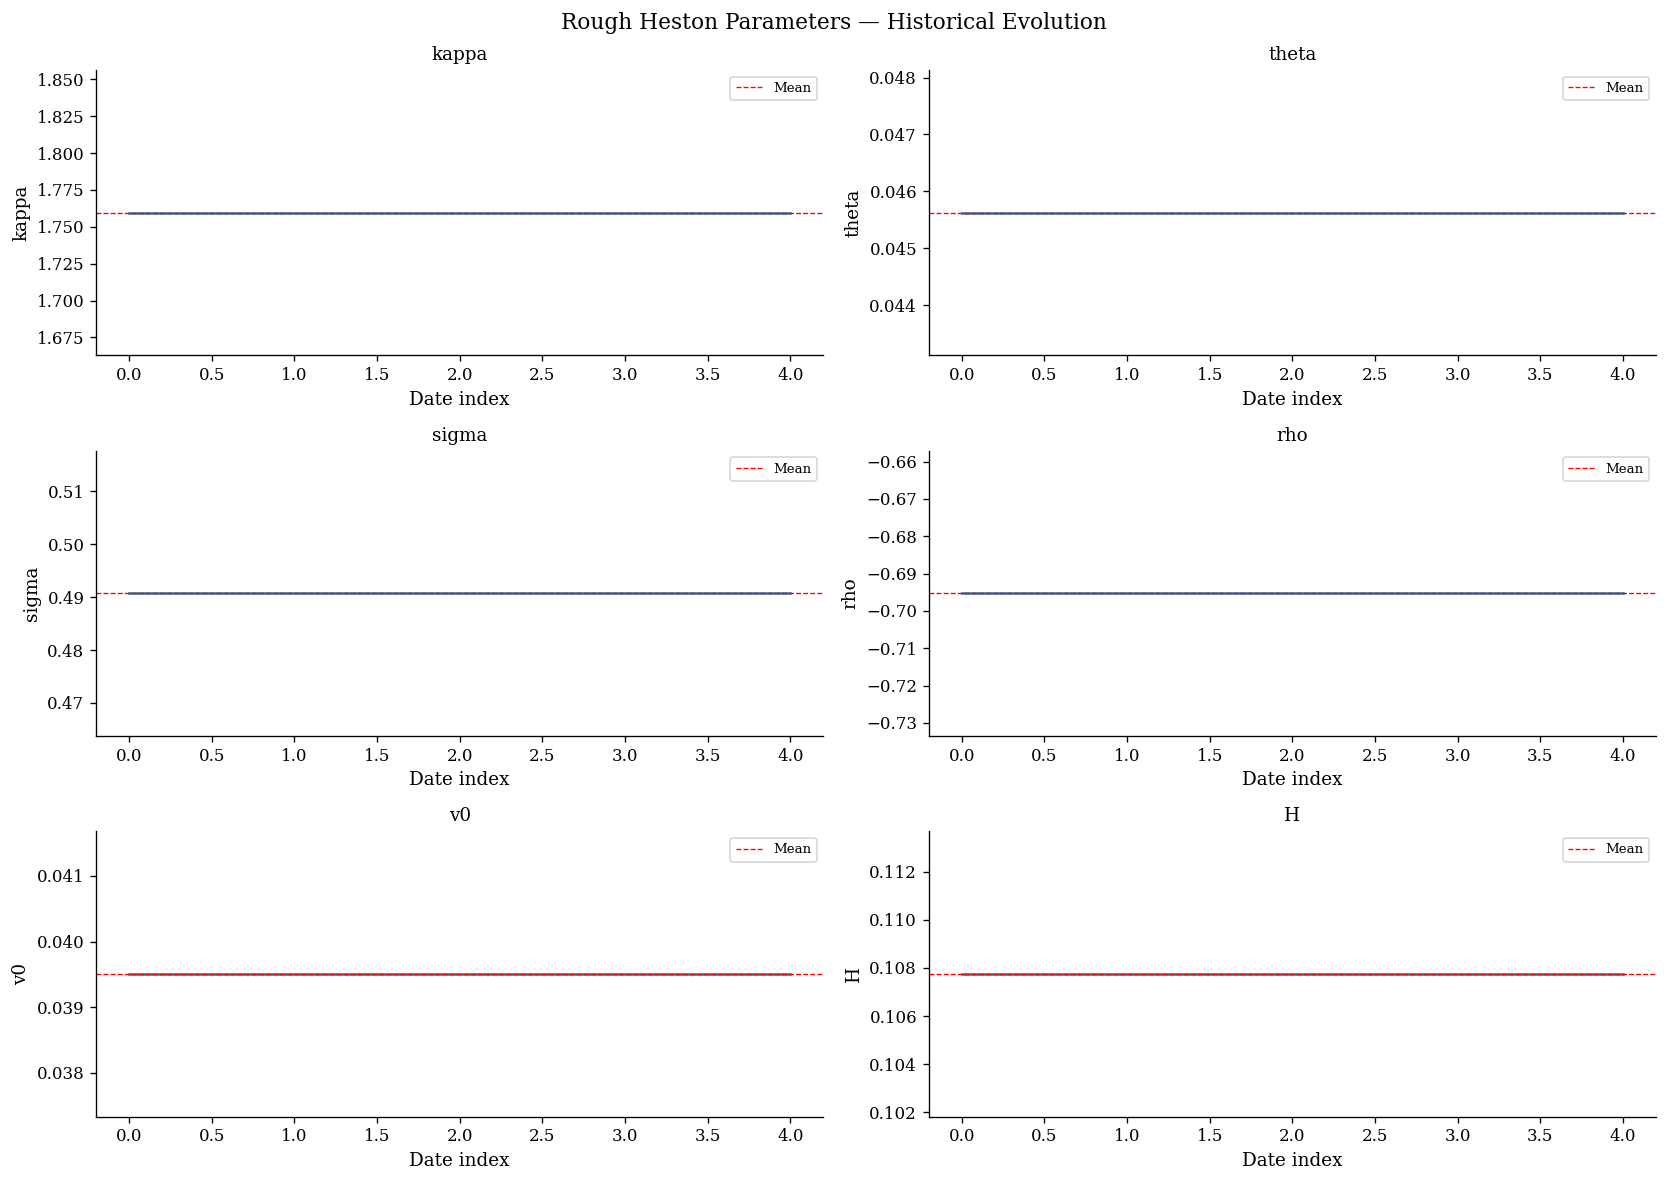

In [4]:
if "date" in df.columns:
    try:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date")
    except Exception:
        pass

params = ["kappa","theta","sigma","rho","v0","H"]
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, param in zip(axes.flat, params):
    ax.plot(range(len(conv)), conv[param], lw=1.5, color="#2d6a9f")
    ax.axhline(conv[param].mean(), color="r", ls="--", lw=0.8, label="Mean")
    ax.set_title(param, fontsize=11); ax.set_ylabel(param)
    ax.set_xlabel("Date index"); ax.legend(fontsize=8)
plt.suptitle("Rough Heston Parameters — Historical Evolution", fontsize=13)
plt.tight_layout(); plt.show()


## 4. Hurst Exponent H — Detailed Analysis

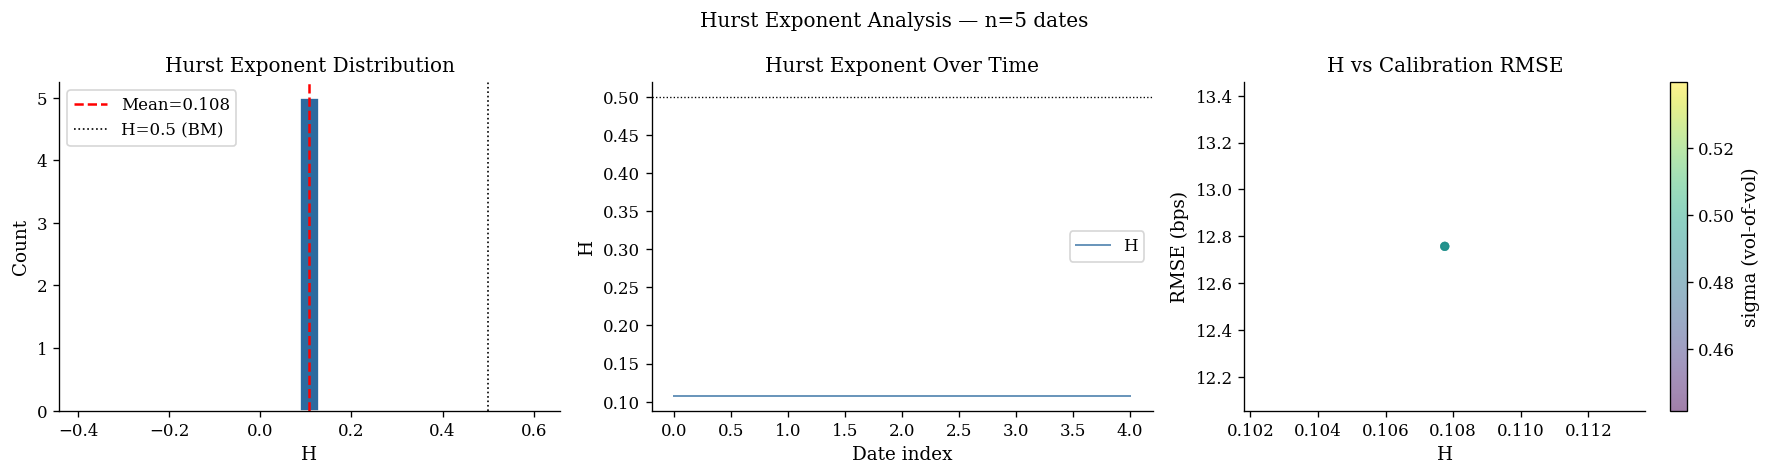

H < 0.5 in 100.0% of dates (rough regime)


In [5]:
H_series = conv["H"].values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(H_series, bins=25, color="#2d6a9f", edgecolor="white")
axes[0].axvline(H_series.mean(), color="r", ls="--", lw=1.5, label=f"Mean={H_series.mean():.3f}")
axes[0].axvline(0.5, color="k", ls=":", lw=1, label="H=0.5 (BM)")
axes[0].set_xlabel("H"); axes[0].set_ylabel("Count")
axes[0].set_title("Hurst Exponent Distribution"); axes[0].legend()

# Time series with rolling mean
axes[1].plot(range(len(H_series)), H_series, lw=1.2, alpha=0.7, color="#2d6a9f", label="H")
if len(H_series) >= 10:
    roll = pd.Series(H_series).rolling(10, min_periods=1).mean()
    axes[1].plot(range(len(H_series)), roll, "r-", lw=2, label="10-day MA")
axes[1].axhline(0.5, color="k", ls=":", lw=0.8)
axes[1].set_xlabel("Date index"); axes[1].set_ylabel("H")
axes[1].set_title("Hurst Exponent Over Time"); axes[1].legend()

# H vs RMSE
sc = axes[2].scatter(H_series, conv["rmse_bps"], alpha=0.5, s=20, c=conv["sigma"], cmap="viridis")
axes[2].set_xlabel("H"); axes[2].set_ylabel("RMSE (bps)")
axes[2].set_title("H vs Calibration RMSE")
plt.colorbar(sc, ax=axes[2], label="sigma (vol-of-vol)")

plt.suptitle(f"Hurst Exponent Analysis — n={len(H_series)} dates")
plt.tight_layout(); plt.show()
print(f"H < 0.5 in {100*(H_series < 0.5).mean():.1f}% of dates (rough regime)")


## 5. RMSE Distribution

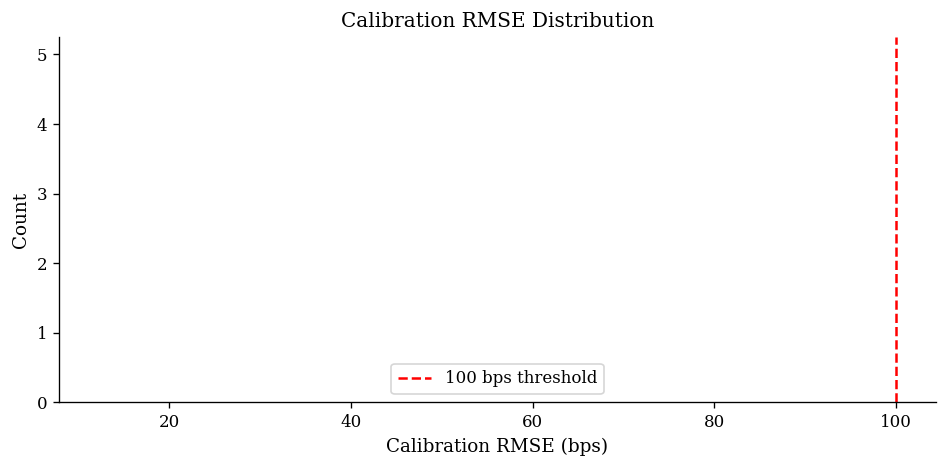

100.0% of calibrations achieved RMSE < 100 bps


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(conv["rmse_bps"], bins=30, color="#27ae60", edgecolor="white")
ax.axvline(100, color="r", ls="--", lw=1.5, label="100 bps threshold")
ax.set_xlabel("Calibration RMSE (bps)"); ax.set_ylabel("Count")
ax.set_title("Calibration RMSE Distribution"); ax.legend()
plt.tight_layout(); plt.show()
under100 = (conv["rmse_bps"] < 100).mean() * 100
print(f"{under100:.1f}% of calibrations achieved RMSE < 100 bps")
